Analyzing homeless shelter data in the GTA

# READ BEFORE RUNNING

Download https://github.com/m4ggie/SDSSDatathon2026/blob/main/postal_codes_geocoded.csv and upload postal_codes_geocoded.csv and the data files as public_services_dataset.xlsx to the runtime to run this code

# Imports

In [25]:
!pip install folium
!pip install geopy
!pip install matplotlib
!pip install pandas
!pip install pgeocode

In [26]:
import folium
import geopandas as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pgeocode
import itertools
import requests
import time

from google.colab import drive
from google.colab import userdata
from geopy.geocoders import Nominatim


## Read data

Read in provided dataset, due to rules restricting redistribution,user must have access to it, download it, and upload to the runtime to read

In [27]:
df = pd.read_excel("public_services_dataset.xlsx")

In [28]:
df.head()

,OCCUPANCY_DATE,LOCATION_POSTAL_CODE,SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE
0,2024-01-01,M9W1J1,Families,Motel/Hotel Shelter,Emergency,Temporary Refugee Response,Room Based Capacity,149,149,1,1.0
1,2024-01-01,M9W1J1,Mixed Adult,Motel/Hotel Shelter,Emergency,Temporary Refugee Response,Room Based Capacity,57,57,0,1.0
2,2024-01-01,M5S2P1,Mixed Adult,Shelter,Emergency,Base Program - Refugee,Bed Based Capacity,8,8,0,1.0
3,2024-01-01,M2J4R1,Families,Motel/Hotel Shelter,Emergency,Temporary Programs,Room Based Capacity,67,67,16,1.0
4,2024-01-01,M2J4R1,Families,Motel/Hotel Shelter,Emergency,Temporary Refugee Response,Room Based Capacity,161,161,0,1.0


# Data cleaning

## Continuous data cleaning

Most of the columns are pretty clean, but do a runthrough to double check

In [29]:
#clean actual_capacity
drop_actual_capacity = df[df['ACTUAL_CAPACITY']<0]
drop_actual_capacity.shape
clean_df = df.drop(drop_actual_capacity.index)

In [30]:
#clean occupied_capacity
drop_occupied_capacity = df[df['OCCUPIED_CAPACITY']<0]
drop_occupied_capacity.shape
clean_df = df.drop(drop_occupied_capacity.index)

In [31]:
#clean unavailable_capacity
drop_unavail_cap = df[df['UNAVAILABLE_CAPACITY']<0]
drop_unavail_cap
drop_unavail_cap.shape
clean_df = df.drop(drop_unavail_cap.index)

In [32]:
#clean occupancy_rate
drop_occupancy_rate = df[df['OCCUPANCY_RATE']<0]
drop_occupancy_rate
drop_occupancy_rate.shape
clean_df = df.drop(drop_occupancy_rate.index)

## Categorical data cleaning

In [33]:
drop_location_postal_code = df[df['LOCATION_POSTAL_CODE'] == 'NAN']
drop_location_postal_code
drop_location_postal_code.shape
clean_df = df.drop(drop_location_postal_code.index)

In [34]:
drop_program_model = df[pd.isna(df['PROGRAM_MODEL'])]
drop_program_model
drop_program_model.shape
clean_df = df.drop(drop_program_model.index)


# EDA

SECTOR
Mixed Adult    28780
Men            25994
Women          17784
Youth          17386
Families       10393
Name: count, dtype: int64


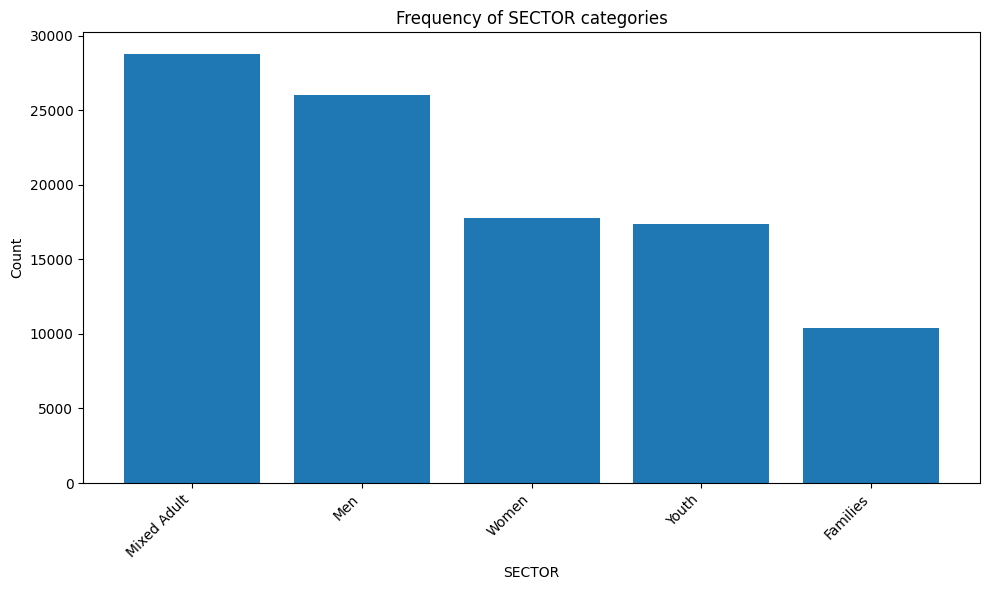

In [35]:
sector_frequency_table = df['SECTOR'].value_counts()
print(sector_frequency_table.head())

plt.figure(figsize=(10, 6))
plt.bar(sector_frequency_table.index, sector_frequency_table.values)
plt.title('Frequency of SECTOR categories')
plt.xlabel('SECTOR')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Finding: There are the most shelters dedicated to mixed adults, then men, women, youth, and families respectively

PROGRAM_MODEL
Emergency       80037
Transitional    20296
Name: count, dtype: int64


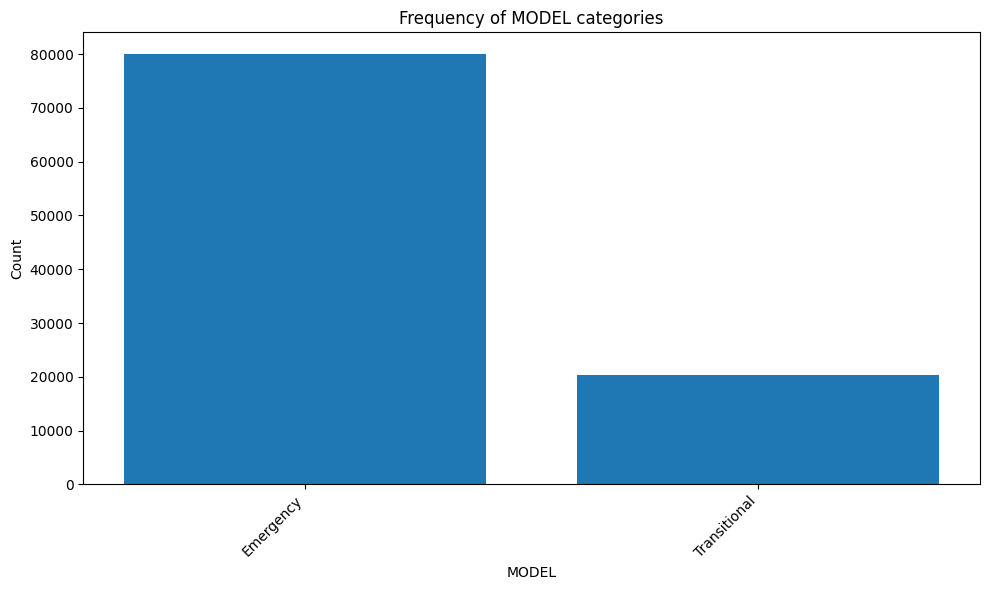

In [36]:
model_frequency_table = df['PROGRAM_MODEL'].value_counts()
print(model_frequency_table.head())

plt.figure(figsize=(10, 6))
plt.bar(model_frequency_table.index, model_frequency_table.values)
plt.title('Frequency of MODEL categories')
plt.xlabel('MODEL')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Finding: A majority of shelters are emergency


PROGRAM_AREA
Base Shelter and Overnight Services System    64008
Temporary Programs                            15926
Temporary Refugee Response                     9534
Base Program - Refugee                         5686
Winter Programs                                5183
Name: count, dtype: int64


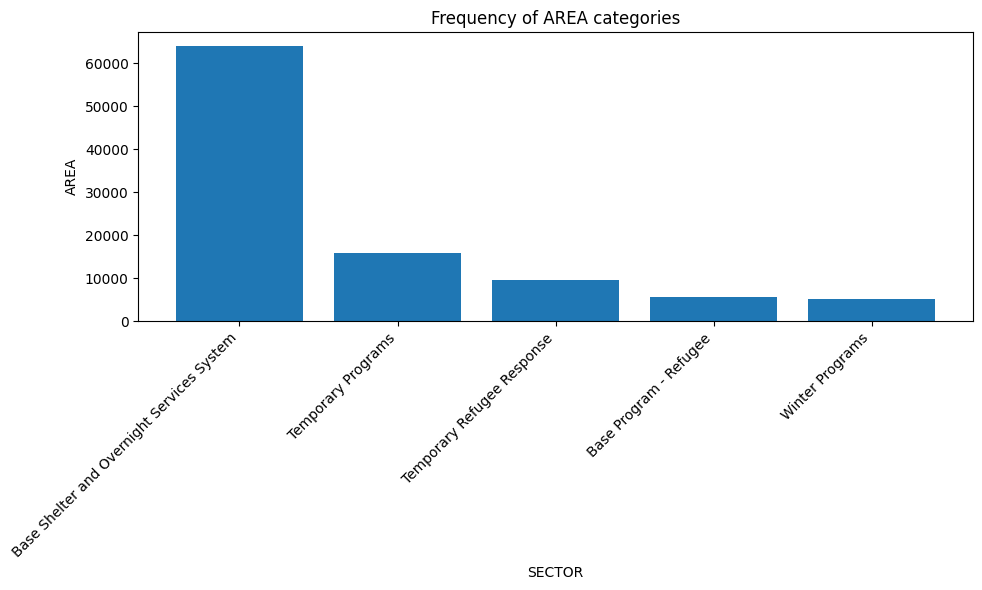

In [37]:
area_frequency_table = df['PROGRAM_AREA'].value_counts()
print(area_frequency_table.head())

plt.figure(figsize=(10, 6))
plt.bar(area_frequency_table.index, area_frequency_table.values)
plt.title('Frequency of AREA categories')
plt.xlabel('SECTOR')
plt.ylabel('AREA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Finding: General base shelter systems are the most common type of area

CAPACITY_TYPE
Bed Based Capacity     73528
Room Based Capacity    26809
Name: count, dtype: int64


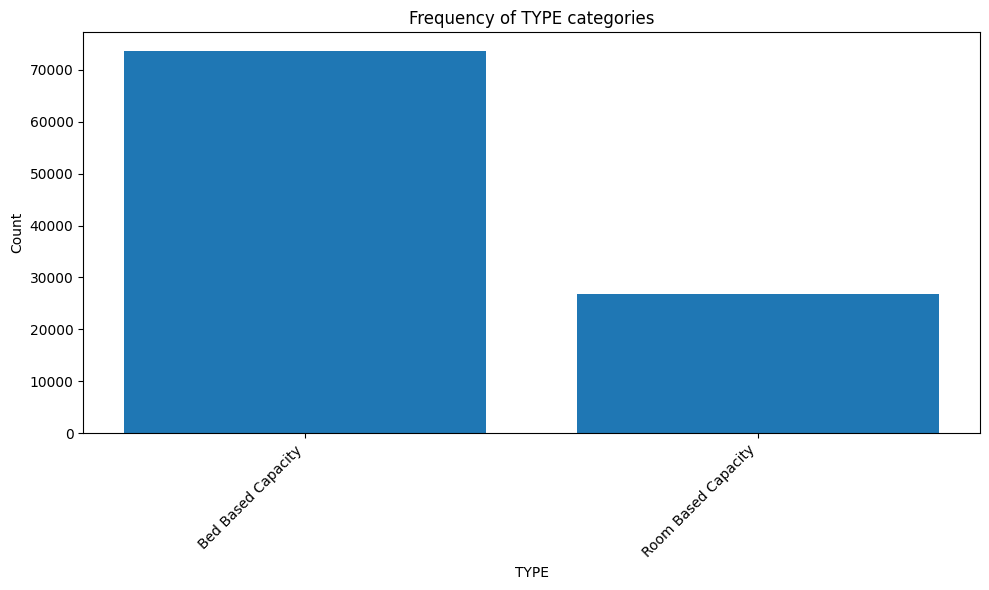

In [38]:
type_frequency_table = df['CAPACITY_TYPE'].value_counts()
print(type_frequency_table.head())

plt.figure(figsize=(10, 6))
plt.bar(type_frequency_table.index, type_frequency_table.values)
plt.title('Frequency of TYPE categories')
plt.xlabel('TYPE')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Geocoding entries -- adding additional information

Each data entry was geocoded using geocodio for easy plotting. This section ensures the the data is consistent with our expectations

In [40]:
geo = pd.read_csv('postal_codes_geocoded.csv')

In [41]:
print(geo.shape)
print(geo.head())

(111, 50)
  country     zip  Geocodio Latitude  Geocodio Longitude  \
0  Canada  M9W1J1          43.690906          -79.578171   
1  Canada  M5S2P1          43.659855          -79.407985   
2  Canada  M2J4R1          43.770090          -79.322980   
3  Canada  M9W6P8          43.716092          -79.594150   
4  Canada  M6R2K3          43.639469          -79.446825   

   Geocodio Accuracy Score Geocodio Accuracy Type  Geocodio Address Line 1  \
0                        1                  place                      NaN   
1                        1                  place                      NaN   
2                        1                  place                      NaN   
3                        1                  place                      NaN   
4                        1                  place                      NaN   

   Geocodio Address Line 2 Geocodio Address Line 3 Geocodio House Number  ...  \
0                      NaN       Etobicoke, ON M9W                   NaN  ...  

In [42]:

m = folium.Map(location=[43.7, -79.4], zoom_start=11)


for index, row in geo.iterrows():
    if pd.notna(row['Geocodio Latitude']) and pd.notna(row['Geocodio Longitude']):
        folium.CircleMarker(
            location=[row['Geocodio Latitude'], row['Geocodio Longitude']],
            radius=5,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
            tooltip=row['zip']  # Display postal code on hover
        ).add_to(m)

m.save('toronto_postal_codes_map.html')
m

In [43]:
clean_df = pd.merge(clean_df, geo[['zip', 'Geocodio Latitude', 'Geocodio Longitude']],
                    left_on='LOCATION_POSTAL_CODE', right_on='zip', how='left')
clean_df = clean_df.drop(columns=['zip']) # Drop the redundant 'zip' column after merge
clean_df = clean_df.rename(columns={'Geocodio Latitude': 'latitude', 'Geocodio Longitude': 'longitude'})
print(clean_df.head())

  OCCUPANCY_DATE LOCATION_POSTAL_CODE       SECTOR OVERNIGHT_SERVICE_TYPE  \
0     2024-01-01               M9W1J1     Families    Motel/Hotel Shelter   
1     2024-01-01               M9W1J1  Mixed Adult    Motel/Hotel Shelter   
2     2024-01-01               M5S2P1  Mixed Adult                Shelter   
3     2024-01-01               M2J4R1     Families    Motel/Hotel Shelter   
4     2024-01-01               M2J4R1     Families    Motel/Hotel Shelter   

  PROGRAM_MODEL                PROGRAM_AREA        CAPACITY_TYPE  \
0     Emergency  Temporary Refugee Response  Room Based Capacity   
1     Emergency  Temporary Refugee Response  Room Based Capacity   
2     Emergency      Base Program - Refugee   Bed Based Capacity   
3     Emergency          Temporary Programs  Room Based Capacity   
4     Emergency  Temporary Refugee Response  Room Based Capacity   

   ACTUAL_CAPACITY  OCCUPIED_CAPACITY  UNAVAILABLE_CAPACITY  OCCUPANCY_RATE  \
0              149                149            

In [44]:
clean_df.to_csv('cleaned_data.csv', index=False)

# Simulation

Read in Cleaned data file

In [45]:
df = pd.read_csv('cleaned_data.csv', sep=',', on_bad_lines='skip')
df.head()

,OCCUPANCY_DATE,LOCATION_POSTAL_CODE,SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE,latitude,longitude
0,2024-01-01,M9W1J1,Families,Motel/Hotel Shelter,Emergency,Temporary Refugee Response,Room Based Capacity,149,149,1,1.0,43.690906,-79.578171
1,2024-01-01,M9W1J1,Mixed Adult,Motel/Hotel Shelter,Emergency,Temporary Refugee Response,Room Based Capacity,57,57,0,1.0,43.690906,-79.578171
2,2024-01-01,M5S2P1,Mixed Adult,Shelter,Emergency,Base Program - Refugee,Bed Based Capacity,8,8,0,1.0,43.659855,-79.407985
3,2024-01-01,M2J4R1,Families,Motel/Hotel Shelter,Emergency,Temporary Programs,Room Based Capacity,67,67,16,1.0,43.770090,-79.322980
4,2024-01-01,M2J4R1,Families,Motel/Hotel Shelter,Emergency,Temporary Refugee Response,Room Based Capacity,161,161,0,1.0,43.770090,-79.322980


In [46]:
df = df.dropna(subset=['latitude', 'longitude']).copy()

## Simulation with results by sector

By looking at the combinations of

(i) Increasing shelter demand by 5%, 10%, or 15%

*This is particularly important as the current data is RIGHT CENSORED, meaning we are not able to identify situations where demand is greater than supply. Increasing demand allows us to simulate having demand being greater than supply, which we know is what is current happening as an average of 223 people were turned away from shelters every night in 2024/2025*

(ii) Fixing the currently temporarily unavailable beds to identify their strain on the system

(iii) Increasing supply of additional beds from external sources (ie. partnerships with motels for refugees)

source: https://www.toronto.ca/news/city-of-toronto-releases-2024-25-winter-services-plan-for-people-experiencing-homelessness/

In [47]:
def simulation(df: pd.DataFrame, demand_increase_pct: int, bed_avail_increase_pct: int, new_beds_avail_pct: int) -> pd.DataFrame:
  """
  Parameters:
  - df: DataFrame containing occupancy data
  - demand_increase_pct: extra percentage of persons added per shelter per night

  Returns:
  - df: DataFrame with demand increase applied

  """
  df = df.copy()

  # forecast
  #simulate increased demand
  df['TOTAL_CAPACITY'] = df['ACTUAL_CAPACITY'] + df['UNAVAILABLE_CAPACITY']
  df['OCCUPIED_CAPACITY'] = df['OCCUPIED_CAPACITY'] * (1+demand_increase_pct)

  #simulate increased beds avail thru fixing broken ones
  df['UNAVAILABLE_CAPACITY'] = df['UNAVAILABLE_CAPACITY'] * (1-bed_avail_increase_pct)
  df['ACTUAL_CAPACITY'] = df['TOTAL_CAPACITY'] - df['UNAVAILABLE_CAPACITY']

  #simulate increased beds avail thru ADDED beds (ie. through motel partnerships)
  df['ACTUAL_CAPACITY'] = df['ACTUAL_CAPACITY'] * (1+new_beds_avail_pct)

  # new column
  df['OVER_CAPACITY'] = df['OCCUPIED_CAPACITY'] > df['ACTUAL_CAPACITY']

  # pivot table containing number of rows (aka nights) per sector
  total_nights = df.groupby('SECTOR').size().reset_index(name='TOTAL_PROGRAM_NIGHTS')

  # create pivot table
  result = df.groupby('SECTOR').agg(
      nights_over_capacity=('OVER_CAPACITY', 'sum')
  ).reset_index()

  # Merge total_nights into result
  result = result.merge(total_nights, on='SECTOR', how='left')

  # calculate percent of sector shelters that are over capacity per sector
  result["percent_over_capacity"] = result["nights_over_capacity"] / result["TOTAL_PROGRAM_NIGHTS"] * 100
  result = result.sort_values("percent_over_capacity", ascending=False)

   # add forecast info columns
  result['demand_increase_pct'] = demand_increase_pct
  result['bed_avail_increase_pct'] = bed_avail_increase_pct
  result['new_beds_avail_pct'] = new_beds_avail_pct

  return result

Preset options for what values to include in the simulation due to time constraints, ideally it would've been a continuous slider.

In [48]:
# iterate through different increases in forecast

cumulative_forecast = pd.DataFrame()

for i in range (1, 4):
  for j in range (0, 3):
    for k in range (0, 5):
      print('i'+ str(i*5) +'j' +str(j*50) +'k' +str(k))
      cumulative_forecast = pd.concat([cumulative_forecast, simulation(df, i*5, j*50, k)])

print(cumulative_forecast.head())
print(cumulative_forecast.shape)


i5j0k0
i5j0k1
i5j0k2
i5j0k3
i5j0k4
i5j50k0
i5j50k1
i5j50k2
i5j50k3
i5j50k4
i5j100k0
i5j100k1
i5j100k2
i5j100k3
i5j100k4
i10j0k0
i10j0k1
i10j0k2
i10j0k3
i10j0k4
i10j50k0
i10j50k1
i10j50k2
i10j50k3
i10j50k4
i10j100k0
i10j100k1
i10j100k2
i10j100k3
i10j100k4
i15j0k0
i15j0k1
i15j0k2
i15j0k3
i15j0k4
i15j50k0
i15j50k1
i15j50k2
i15j50k3
i15j50k4
i15j100k0
i15j100k1
i15j100k2
i15j100k3
i15j100k4
        SECTOR  nights_over_capacity  TOTAL_PROGRAM_NIGHTS  \
0     Families                 10393                 10393   
3        Women                 17782                 17784   
4        Youth                 17370                 17382   
1          Men                 25958                 25994   
2  Mixed Adult                 28685                 28780   

   percent_over_capacity  demand_increase_pct  bed_avail_increase_pct  \
0             100.000000                    5                       0   
3              99.988754                    5                       0   
4              99.

In [49]:
cumulative_forecast.to_csv('forecasted_data.csv')

## Simulate Redistribution across FSAs

If shelters in the same FSA (first three letters of postal code) have too much demand and excess supply, this simulation will distribute to fill the excess supply, ignoring sectors. If improvements arise, this suggests relaxing sector constraints

In [50]:
import numpy as np
import pandas as pd

def redistribution_region(df: pd.DataFrame,
                          demand_increase_pct: float,
                          bed_avail_increase_pct: float,
                          new_beds_avail_pct: float):

    #Deterministic shelter occupancy simulation with FSA redistribution, keeping date and lat/lon.


    df = df.copy()

    #demand and capacity adjustments
    df['TOTAL_CAPACITY'] = df['ACTUAL_CAPACITY'] + df['UNAVAILABLE_CAPACITY']
    df['OCCUPIED_CAPACITY'] *= (1 + demand_increase_pct)
    df['UNAVAILABLE_CAPACITY'] *= (1 - bed_avail_increase_pct)
    df['ACTUAL_CAPACITY'] = df['TOTAL_CAPACITY'] - df['UNAVAILABLE_CAPACITY']
    df['ACTUAL_CAPACITY'] *= (1 + new_beds_avail_pct)

    #calculate baseline over capacity value
    df['OVER_CAPACITY_BASE'] = df['OCCUPIED_CAPACITY'] > df['ACTUAL_CAPACITY']

    total_nights = df.groupby('SECTOR').size().reset_index(name='TOTAL_PROGRAM_NIGHTS')
    result_base = df.groupby('SECTOR').agg(
        nights_over_capacity=('OVER_CAPACITY_BASE', 'sum')
    ).reset_index()
    result_base = result_base.merge(total_nights, on='SECTOR', how='left')
    result_base["percent_over_capacity"] = result_base["nights_over_capacity"] / result_base["TOTAL_PROGRAM_NIGHTS"] * 100


    #FSA Redistribution (regional redistribution within postal code FSA)

    df['FSA'] = df['LOCATION_POSTAL_CODE'].str[:3]
    df['overflow'] = (df['OCCUPIED_CAPACITY'] - df['ACTUAL_CAPACITY']).clip(lower=0)
    df['spare'] = (df['ACTUAL_CAPACITY'] - df['OCCUPIED_CAPACITY']).clip(lower=0)

    group_cols = ['OCCUPANCY_DATE', 'FSA']
    regional = df.groupby(group_cols).agg(
        total_overflow=('overflow', 'sum'),
        total_spare=('spare', 'sum')
    ).reset_index()

    regional['absorbed'] = np.minimum(regional['total_overflow'], regional['total_spare'])

    df = df.merge(regional[group_cols + ['total_overflow', 'total_spare', 'absorbed']],
                  on=group_cols, how='left')

    df['redistribution_in'] = np.where(df['total_spare'] > 0,
                                       (df['spare'] / df['total_spare']) * df['absorbed'], 0)
    df['redistribution_out'] = np.where(df['total_overflow'] > 0,
                                        (df['overflow'] / df['total_overflow']) * df['absorbed'], 0)

    df['OCCUPIED_CAPACITY'] = df['OCCUPIED_CAPACITY'] - df['redistribution_out'] + df['redistribution_in']


    #Recompute over capacity after redistribution
    df['OVER_CAPACITY'] = df['OCCUPIED_CAPACITY'] > df['ACTUAL_CAPACITY']


    #Aggregate results by date + sector
    result_by_date = df.groupby(['OCCUPANCY_DATE', 'SECTOR']).agg(
        nights_over_capacity=('OVER_CAPACITY', 'sum'),
        total_program_nights=('OCCUPIED_CAPACITY', 'count')
    ).reset_index()

    result_by_date["percent_over_capacity"] = result_by_date["nights_over_capacity"] / result_by_date["total_program_nights"] * 100

    #City-wide Redistribution Effectiveness Index (REI)
    system_base = result_base['nights_over_capacity'].sum() / result_base['TOTAL_PROGRAM_NIGHTS'].sum()
    system_redistributed = result_by_date['nights_over_capacity'].sum() / result_by_date['total_program_nights'].sum()

    if system_base > 0:
        system_REI = (system_base - system_redistributed) / system_base
    else:
        system_REI = 0.0

    #Add scenario info

    result_by_date['demand_increase_pct'] = demand_increase_pct
    result_by_date['bed_avail_increase_pct'] = bed_avail_increase_pct
    result_by_date['new_beds_avail_pct'] = new_beds_avail_pct
    result_by_date['system_REI'] = system_REI

    # Shelter-level output for mapping
    map_df = df[['OCCUPANCY_DATE', 'SECTOR', 'LOCATION_POSTAL_CODE',
                 'latitude', 'longitude', 'OCCUPIED_CAPACITY', 'ACTUAL_CAPACITY', 'OVER_CAPACITY']].copy()

    map_df['demand_increase_pct'] = demand_increase_pct
    map_df['bed_avail_increase_pct'] = bed_avail_increase_pct
    map_df['new_beds_avail_pct'] = new_beds_avail_pct
    map_df['system_REI'] = system_REI

    return result_by_date, map_df, system_REI

In [51]:
cumulative_map_df = pd.DataFrame()

for i in range(1, 4):
    for j in range(0, 3):
        for k in range(0, 5):
            demand_frac = i * 0.05
            bed_fix_frac = j * 0.50
            new_beds_frac = k * 0.01

            # Get shelter-level output (map_df)
            _, map_res, system_REI = redistribution_region(df, demand_frac, bed_fix_frac, new_beds_frac)

            # Add scenario info (already added in function)
            cumulative_map_df = pd.concat([cumulative_map_df, map_res], ignore_index=True)

print(cumulative_map_df.head())
print(cumulative_map_df.shape)

  OCCUPANCY_DATE       SECTOR LOCATION_POSTAL_CODE   latitude  longitude  \
0     2024-01-01     Families               M9W1J1  43.690906 -79.578171   
1     2024-01-01  Mixed Adult               M9W1J1  43.690906 -79.578171   
2     2024-01-01  Mixed Adult               M5S2P1  43.659855 -79.407985   
3     2024-01-01     Families               M2J4R1  43.770090 -79.322980   
4     2024-01-01     Families               M2J4R1  43.770090 -79.322980   

   OCCUPIED_CAPACITY  ACTUAL_CAPACITY  OVER_CAPACITY  demand_increase_pct  \
0         156.450000            149.0           True                 0.05   
1          59.850000             57.0           True                 0.05   
2           8.193103              8.0           True                 0.05   
3          70.350000             67.0           True                 0.05   
4         169.050000            161.0           True                 0.05   

   bed_avail_increase_pct  new_beds_avail_pct  system_REI  
0                   